# 03 Exploratory Data Analysis



Cell 1 — Setup & Load Data


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == 'notebooks' else Path.cwd().resolve()

In [4]:
DATA_PATH = PROJECT_ROOT / 'data/processed/Beijing PM25 Data Cleaned.csv'
df = pd.read_csv(DATA_PATH)
df.head()

,datetime,year,month,day,hour,pm2_5,pm2_5_cleaned,dew_point,temperature,pressure,wind_direction,wind_speed,hours_snow,hours_rain
0,2010-01-01 00:00:00,2010,1,1,0,NaN,129.0,-21,-11.0,1021.0,NW,1.79,0,0
1,2010-01-01 01:00:00,2010,1,1,1,NaN,129.0,-21,-12.0,1020.0,NW,4.92,0,0
2,2010-01-01 02:00:00,2010,1,1,2,NaN,129.0,-21,-11.0,1019.0,NW,6.71,0,0
3,2010-01-01 03:00:00,2010,1,1,3,NaN,129.0,-21,-14.0,1019.0,NW,9.84,0,0
4,2010-01-01 04:00:00,2010,1,1,4,NaN,129.0,-20,-12.0,1018.0,NW,12.97,0,0


In [5]:
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
datetime,43824,NaN,NaN,NaN,2012-07-01 23:30:00,2010-01-01 00:00:00,2011-04-02 11:45:00,2012-07-01 23:30:00,2013-10-01 11:15:00,2014-12-31 23:00:00,NaN
year,43824.0,NaN,NaN,NaN,2012.0,2010.0,2011.0,2012.0,2013.0,2014.0,1.413842
month,43824.0,NaN,NaN,NaN,6.523549,1.0,4.0,7.0,10.0,12.0,3.448572
day,43824.0,NaN,NaN,NaN,15.72782,1.0,8.0,16.0,23.0,31.0,8.799425
hour,43824.0,NaN,NaN,NaN,11.5,0.0,5.75,11.5,17.25,23.0,6.922266
pm2_5,41757.0,NaN,NaN,NaN,98.613215,0.0,29.0,72.0,137.0,994.0,92.050387
pm2_5_cleaned,43824.0,NaN,NaN,NaN,97.801114,0.0,29.0,72.0,136.0,994.0,91.376429
dew_point,43824.0,NaN,NaN,NaN,1.817246,-40.0,-10.0,2.0,15.0,28.0,14.43344
temperature,43824.0,NaN,NaN,NaN,12.448521,-19.0,2.0,14.0,23.0,42.0,12.198613
pressure,43824.0,NaN,NaN,NaN,1016.447654,991.0,1008.0,1016.0,1025.0,1046.0,10.268698


# Plot 1 — PM2.5 Distribution (Histogram)



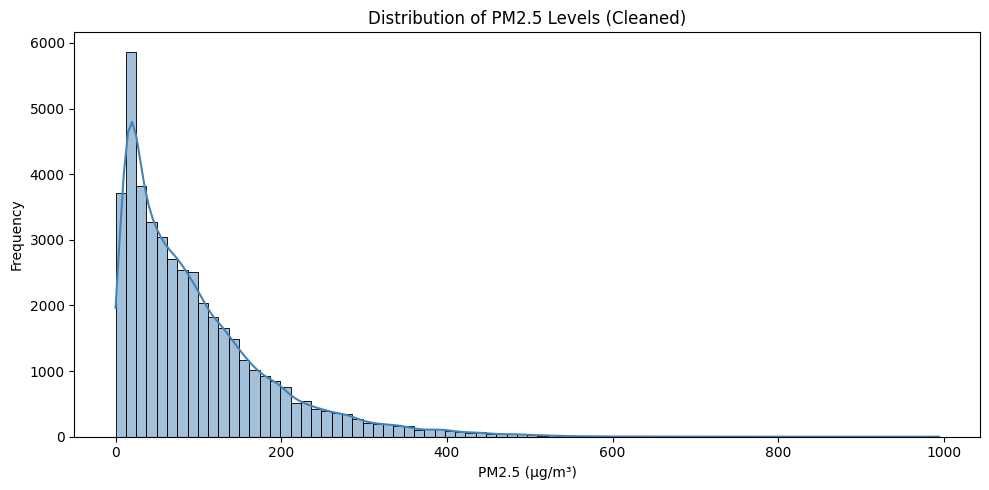

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df['pm2_5_cleaned'].dropna(), bins=80, kde=True, color='steelblue')
plt.title('Distribution of PM2.5 Levels (Cleaned)')
plt.xlabel('PM2.5 (µg/m³)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('plot1_pm25_distribution.png', dpi=150)
plt.show()

PM2.5 levels are heavily right-skewed (skewness = 1.82), with a mean of 97.8 µg/m³ — over 6× the WHO safe limit of 15 µg/m³. The long tail shows extreme pollution events reaching up to 994 µg/m³. 21.2% of all hours exceed 150 µg/m³, indicating hazardous conditions are not rare but a recurring pattern in Beijing.

# Plot 2 — Monthly Average PM2.5 (Bar Chart)

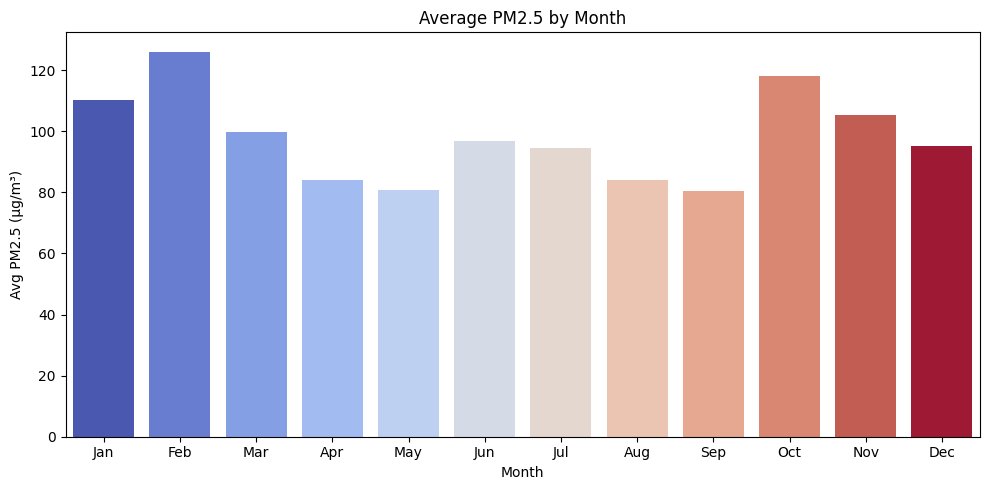

In [8]:
monthly_avg = df.groupby('month')['pm2_5_cleaned'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, hue=monthly_avg.index, palette='coolwarm', legend=False)
plt.xticks(ticks=range(12), labels=month_names)
plt.title('Average PM2.5 by Month')
plt.xlabel('Month')
plt.ylabel('Avg PM2.5 (µg/m³)')
plt.tight_layout()
plt.savefig('plot2_monthly_avg_pm25.png', dpi=150)
plt.show()

PM2.5 is highest in February (126.1 µg/m³) and October (118.2 µg/m³), and lowest in September (80.5 µg/m³) and May (80.9 µg/m³). The winter and late-autumn spike is consistent with increased coal heating, lower atmospheric mixing, and reduced wind dispersion during colder months.

# Plot 3 — Hourly Average PM2.5 (Line Plot)

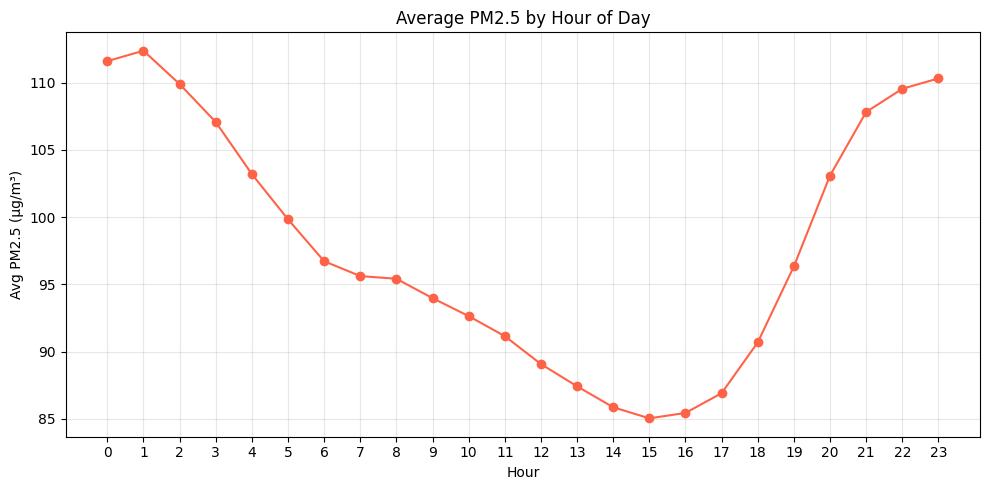

In [9]:
hourly_avg = df.groupby('hour')['pm2_5_cleaned'].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o', color='tomato')
plt.title('Average PM2.5 by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg PM2.5 (µg/m³)')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot3_hourly_avg_pm25.png', dpi=150)
plt.show()

PM2.5 is highest between midnight and 2am (peaking at 112.4 µg/m³ at 1am) and lowest in the mid-afternoon around 3–4pm (85 µg/m³). This pattern reflects reduced atmospheric turbulence and temperature inversion at night, which traps pollutants near ground level, while afternoon heating disperses them.

# Plot 4  — Monthly PM2.5 by Year (Multi-Line)

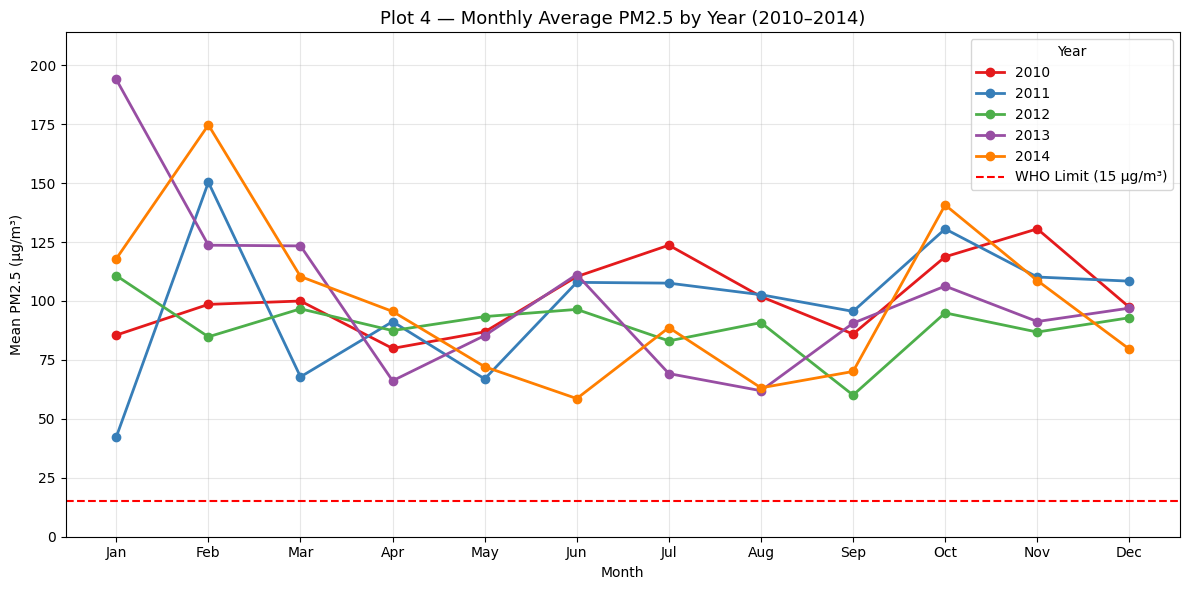

In [ ]:
# Ensure year exists
df['year'] = df['datetime'].dt.year

month_year = df.groupby(['year','month'])['pm2_5_cleaned'].mean().reset_index()

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00']

plt.figure(figsize=(12, 6))

for i, year in enumerate(sorted(month_year['year'].unique())):
    data = month_year[month_year['year'] == year]
    plt.plot(data['month'], data['pm2_5_cleaned'],
             marker='o', linewidth=2, markersize=6,
             color=colors[i], label=str(year))


WHO_LIMIT = 15  
plt.axhline(WHO_LIMIT, color='red', linestyle='--',
            linewidth=1.5, label=f'WHO Limit ({WHO_LIMIT} µg/m³)')

plt.xticks(range(1, 13), month_names)


plt.ylim(0, month_year['pm2_5_cleaned'].max() + 20)

plt.title('Plot 4 — Monthly Average PM2.5 by Year (2010–2014)', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Mean PM2.5 (µg/m³)')

plt.legend(title='Year', loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()


plt.savefig('plot4_monthly_yearly_lines.png', dpi=150)

plt.show()

Pollution patterns are consistent across all five years, with winter/autumn peaks recurring annually. However, January 2013 stands out as an extreme outlier at 193.9 µg/m³, likely corresponding to the widely reported "airpocalypse" event. No clear year-on-year improvement is visible — levels remain persistently high across 2010–2014.

# Plot 5 — Correlation Heatmap

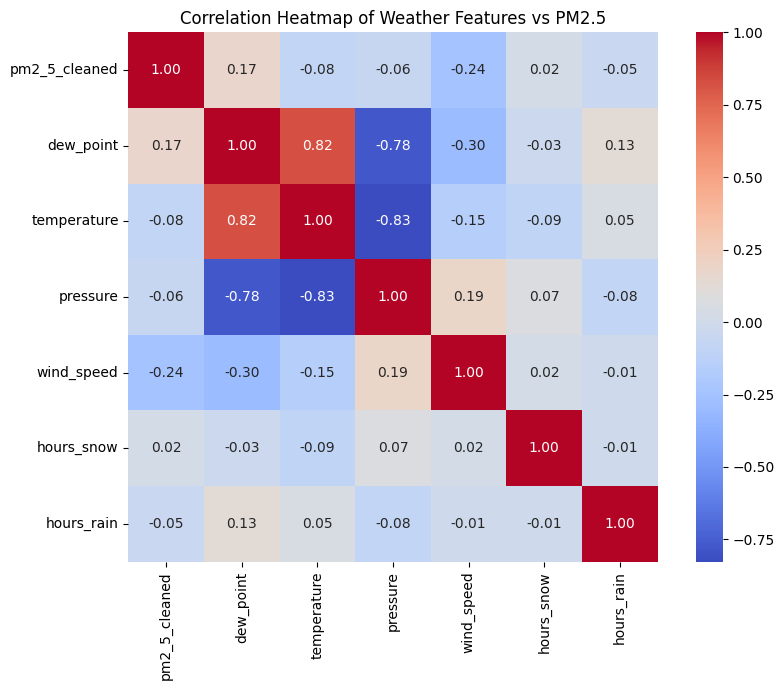

In [14]:
num_cols = ['pm2_5_cleaned', 'dew_point', 'temperature', 'pressure', 'wind_speed', 'hours_snow', 'hours_rain']

plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Weather Features vs PM2.5')
plt.tight_layout()
plt.savefig('plot5_correlation_heatmap.png', dpi=150)
plt.show()

Wind speed has the strongest negative correlation with PM2.5 (r = −0.24), confirming that higher winds disperse pollutants. Dew point shows a modest positive correlation (r = 0.18), suggesting humid, stagnant conditions are associated with higher pollution. Temperature, pressure, rain, and snow show weak linear correlations, though non-linear relationships may still exist.

# Plot 6 — Wind Direction vs PM2.5 (Bar Chart)

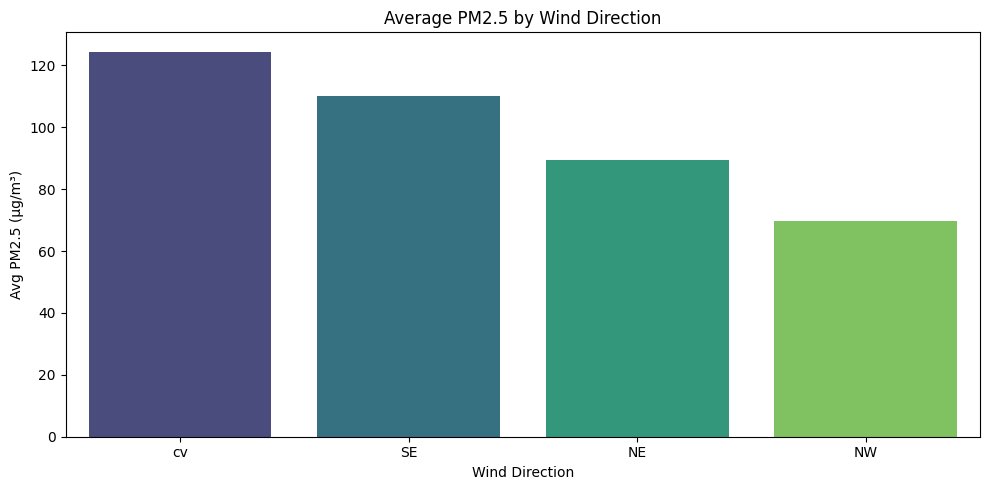

In [15]:
wind_pm = df.groupby('wind_direction')['pm2_5_cleaned'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=wind_pm.index, y=wind_pm.values, hue=wind_pm.index, palette='viridis', legend=False)
plt.title('Average PM2.5 by Wind Direction')
plt.xlabel('Wind Direction')
plt.ylabel('Avg PM2.5 (µg/m³)')
plt.tight_layout()
plt.savefig('plot6_wind_direction_pm25.png', dpi=150)
plt.show()

Calm/variable wind conditions (cv) are associated with the highest average PM2.5 (124.5 µg/m³), while northwesterly winds (NW) correspond to the lowest (69.8 µg/m³). This strongly suggests that wind from the northwest clears pollution, while calm conditions allow it to accumulate — a key signal for alert triggers.

# Plot 7 — AQI Category Breakdown (Donut Chart)

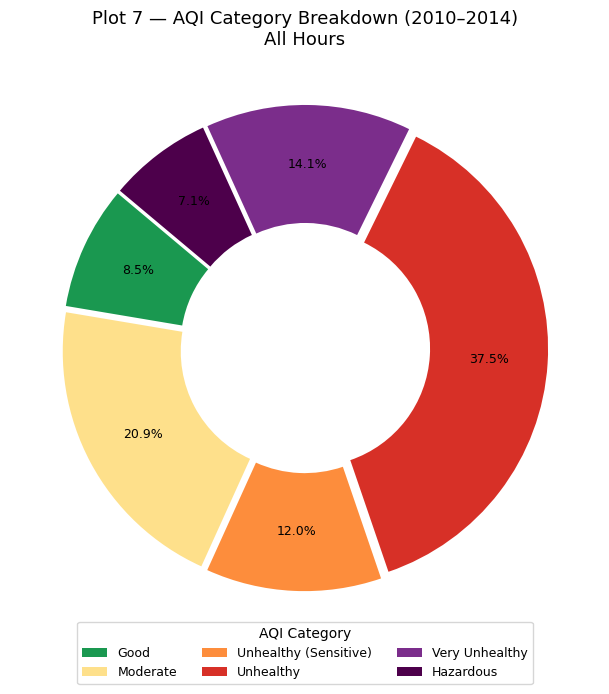

Good                          :   3707 hrs (8.5%)
Moderate                      :   9151 hrs (20.9%)
Unhealthy (Sensitive)         :   5267 hrs (12.0%)
Unhealthy                     :  16429 hrs (37.5%)
Very Unhealthy                :   6160 hrs (14.1%)
Hazardous                     :   3110 hrs (7.1%)


In [ ]:
def aqi_category(pm):
    if pm <= 12:      return 'Good'
    elif pm <= 35.4:  return 'Moderate'
    elif pm <= 55.4:  return 'Unhealthy (Sensitive)'
    elif pm <= 150.4: return 'Unhealthy'
    elif pm <= 250.4: return 'Very Unhealthy'
    else:             return 'Hazardous'

df['aqi_cat'] = df['pm2_5_cleaned'].apply(aqi_category)

aqi_counts = df['aqi_cat'].value_counts().reindex([
    'Good','Moderate','Unhealthy (Sensitive)','Unhealthy','Very Unhealthy','Hazardous'
]).dropna()

colors = ['#1a9850','#fee08b','#fd8d3c','#d73027','#7b2d8b','#4d004b']
explode = [0.03] * len(aqi_counts)

fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie(
    aqi_counts, labels=None, autopct='%1.1f%%',
    colors=colors, explode=explode,
    wedgeprops=dict(width=0.5), startangle=140,
    pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(9)

ax.legend(wedges, aqi_counts.index, title='AQI Category',
          loc='lower center', bbox_to_anchor=(0.5, -0.08),
          ncol=3, fontsize=9)
ax.set_title('Plot 7 — AQI Category Breakdown (2010–2014)\nAll Hours', fontsize=13)
plt.tight_layout()
plt.savefig('plot7_aqi_donut.png', dpi=150)
plt.show()


for cat, count in aqi_counts.items():
    print(f"{cat:30s}: {count:6d} hrs ({count/len(df)*100:.1f}%)")

Only 8.5% of hours fall in the "Good" category. The majority — 37.5% — are classified as "Unhealthy", and a combined 21.2% fall in "Very Unhealthy" or "Hazardous" ranges. This means Beijing air is unsafe for the general population for over half of all recorded hours, underscoring the urgency of a decision-support system.

# Plot 8 — Hazardous Days per Year (Bar Chart)

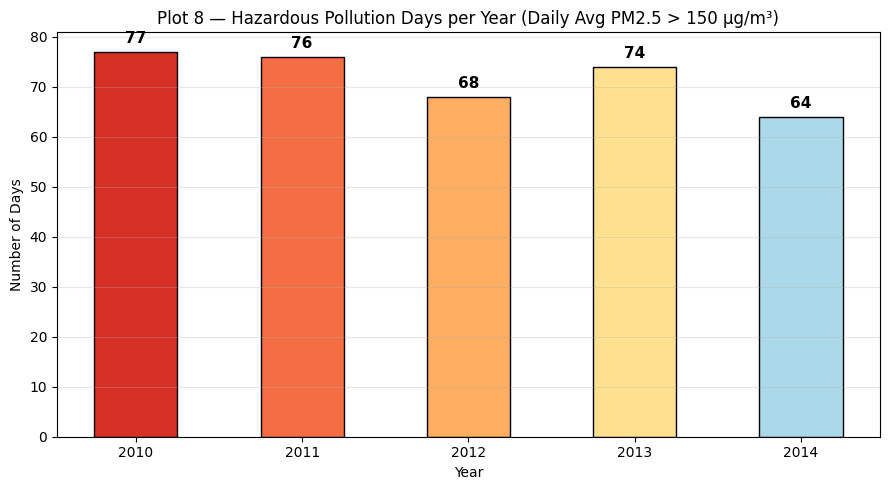

   year  hazardous_days
0  2010              77
1  2011              76
2  2012              68
3  2013              74
4  2014              64


In [17]:
df['date'] = df['datetime'].dt.date
daily_avg = df.groupby(['year','date'])['pm2_5_cleaned'].mean().reset_index()
daily_avg['hazardous'] = daily_avg['pm2_5_cleaned'] > 150
hazardous_days = daily_avg.groupby('year')['hazardous'].sum().reset_index()
hazardous_days.columns = ['year', 'hazardous_days']

plt.figure(figsize=(9, 5))
bars = plt.bar(hazardous_days['year'].astype(str),
               hazardous_days['hazardous_days'],
               color=['#d73027','#f46d43','#fdae61','#fee090','#abd9e9'],
               edgecolor='black', width=0.5)
plt.bar_label(bars, fmt='%d', padding=4, fontsize=11, fontweight='bold')
plt.title('Plot 8 — Hazardous Pollution Days per Year (Daily Avg PM2.5 > 150 µg/m³)', fontsize=12)
plt.xlabel('Year')
plt.ylabel('Number of Days')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot8_hazardous_days.png', dpi=150)
plt.show()
print(hazardous_days)

Hazardous days (daily average PM2.5 > 150 µg/m³) range from 64 (2014) to 77 (2010), meaning roughly 1 in 5 days every year are hazardous. There is a slight declining trend from 2010 to 2014, but the numbers remain critically high throughout the period.

# Plot 9 — Seasonal Mean PM2.5 vs WHO Limit

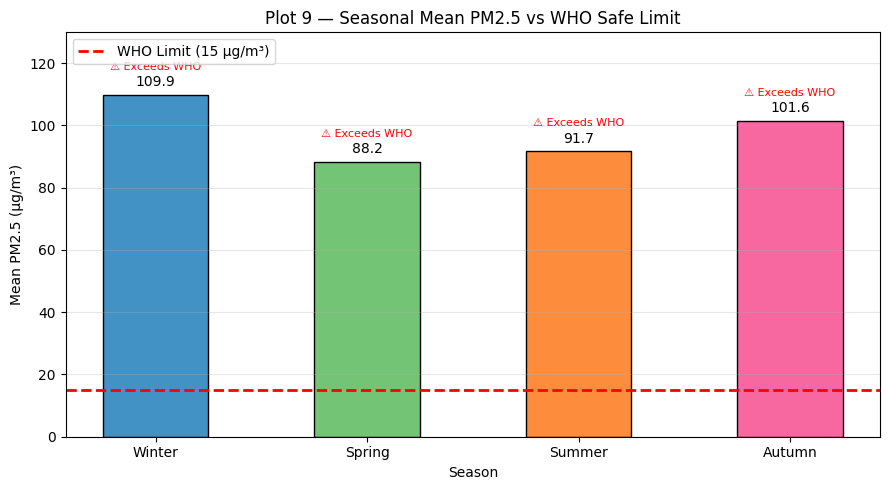

In [25]:
season_order = ['Winter','Spring','Summer','Autumn']
df['season'] = df['month'].map({12:'Winter',1:'Winter',2:'Winter',
                                 3:'Spring',4:'Spring',5:'Spring',
                                 6:'Summer',7:'Summer',8:'Summer',
                                 9:'Autumn',10:'Autumn',11:'Autumn'})

season_order = ['Winter','Spring','Summer','Autumn']
seasonal = df.groupby('season')['pm2_5_cleaned'].mean().reindex(season_order)
colors = ['#4292c6','#74c476','#fd8d3c','#f768a1']
WHO_LIMIT = 15
seasonal = df.groupby('season')['pm2_5_cleaned'].mean().reindex(season_order)
colors = ['#4292c6','#74c476','#fd8d3c','#f768a1']
WHO_LIMIT = 15

plt.figure(figsize=(9, 5))
bars = plt.bar(seasonal.index, seasonal.values,
               color=colors, edgecolor='black', width=0.5)
plt.axhline(WHO_LIMIT, color='red', linestyle='--',
            linewidth=2, label=f'WHO Limit ({WHO_LIMIT} µg/m³)')
plt.bar_label(bars, fmt='%.1f', padding=4, fontsize=10)
plt.ylim(0, max(seasonal.values) + 20)

for i, (season, val) in enumerate(seasonal.items()):
    if val > WHO_LIMIT:
        plt.text(i, val + 8, '⚠ Exceeds WHO',
                 ha='center', fontsize=8, color='red')

plt.title('Plot 9 — Seasonal Mean PM2.5 vs WHO Safe Limit', fontsize=12)
plt.xlabel('Season')
plt.ylabel('Mean PM2.5 (µg/m³)')
plt.legend(loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot9_seasonal_who.png', dpi=150)
plt.show()

Winter has the highest seasonal mean (109.9 µg/m³) followed by Autumn (101.6 µg/m³). All four seasons exceed the WHO limit by at least 5×, but the winter–summer gap of ~18 µg/m³ confirms that season is a meaningful predictor for targeted alert timing.

# Plot 10 — Precipitation Effect on PM2.5

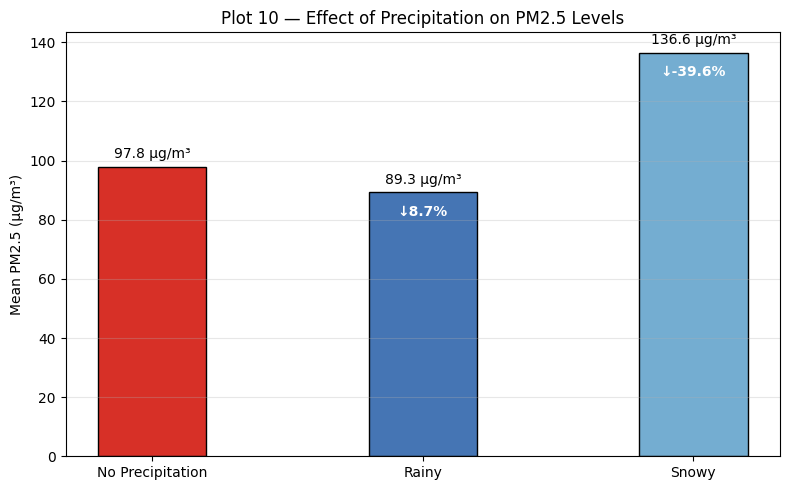

precip_type
No Precipitation     97.83
Rainy                89.33
Snowy               136.55
Name: pm2_5_cleaned, dtype: float64


In [26]:
df['precip_type'] = 'No Precipitation'
df.loc[df['hours_rain'] > 0, 'precip_type'] = 'Rainy'
df.loc[df['hours_snow'] > 0, 'precip_type'] = 'Snowy'

precip_mean = df.groupby('precip_type')['pm2_5_cleaned'].mean().reindex(
    ['No Precipitation','Rainy','Snowy'])

no_precip_val = precip_mean['No Precipitation']
colors = ['#d73027','#4575b4','#74add1']

plt.figure(figsize=(8, 5))
bars = plt.bar(precip_mean.index, precip_mean.values,
               color=colors, edgecolor='black', width=0.4)
plt.bar_label(bars, fmt='%.1f µg/m³', padding=4, fontsize=10)

# Annotate % reduction
for i, (label, val) in enumerate(precip_mean.items()):
    if label != 'No Precipitation':
        pct = ((no_precip_val - val) / no_precip_val) * 100
        plt.text(i, val - 8, f'↓{pct:.1f}%', ha='center',
                 fontsize=10, color='white', fontweight='bold')

plt.title('Plot 10 — Effect of Precipitation on PM2.5 Levels', fontsize=12)
plt.ylabel('Mean PM2.5 (µg/m³)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot10_precipitation_effect.png', dpi=150)
plt.show()
print(precip_mean.round(2))

Rainy conditions show slightly lower PM2.5 (89.3 µg/m³) compared to dry conditions (97.8 µg/m³), but the difference is modest. Surprisingly, snowy conditions show the highest mean (136.6 µg/m³), likely because snow occurs in winter when pollution is already elevated, making snow a confounded indicator rather than a driver.

# Plot 11 — Annual Mean PM2.5 Trend vs WHO Limit

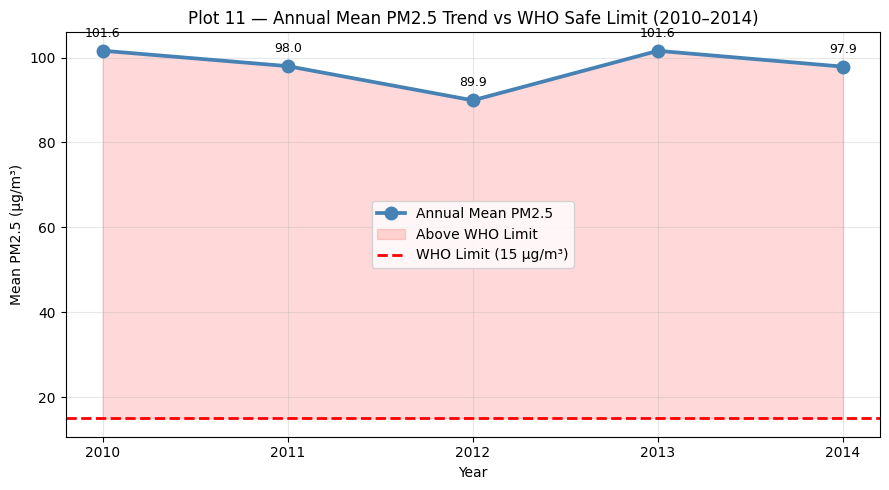

year
2010    101.63
2011     97.99
2012     89.93
2013    101.60
2014     97.87
Name: pm2_5_cleaned, dtype: float64


In [27]:
annual = df.groupby('year')['pm2_5_cleaned'].mean()

plt.figure(figsize=(9, 5))
plt.plot(annual.index, annual.values, marker='o', linewidth=2.7,
         color='steelblue', markersize=9, zorder=5, label='Annual Mean PM2.5')
plt.fill_between(annual.index, annual.values, WHO_LIMIT,
                 where=annual.values > WHO_LIMIT,
                 alpha=0.15, color='red', label='Above WHO Limit')
plt.axhline(WHO_LIMIT, color='red', linestyle='--',
            linewidth=2, label=f'WHO Limit ({WHO_LIMIT} µg/m³)')

# Annotate each point
for yr, val in annual.items():
    plt.annotate(f'{val:.1f}', (yr, val), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=9)

plt.title('Plot 11 — Annual Mean PM2.5 Trend vs WHO Safe Limit (2010–2014)', fontsize=12)
plt.xlabel('Year')
plt.ylabel('Mean PM2.5 (µg/m³)')
plt.xticks(annual.index)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot11_annual_trend_who.png', dpi=150)
plt.show()
print(annual.round(2))

Annual means fluctuate between 89.9 (2012) and 101.6 µg/m³ (2010 and 2013) with no consistent downward trend. All five years remain far above the WHO limit of 15 µg/m³, indicating that the pollution problem did not meaningfully improve over the study period.

